# YOLO 단독 (탐지+분류 통합) — 14대분류 · 1단계 대조 실험

## 목적
지금까지의 **2단계(YOLO 위치탐지 → 별도 분류기)** 설계가 정당한지 확인하기 위한 **1단계 대조군**.
YOLO 하나로 위치+차종을 동시에 예측하게 학습해, 2단계와 같은 잣대(IoU 매칭 후 클래스 정답률)로 비교한다.

## 설계
- 기존 stage1과 달리 **단일 vehicle 통합을 하지 않고**, COCO category(차종 type)를 **14대분류로 매핑**해 YOLO에 직접 학습
- 14대분류 = 민수 4(Car/Truck/Bus/Construction) + MSTAR 10 (분류기 실험과 동일 체계)
- 평가: ① YOLO 표준 mAP50 (논문 YOLOv8 SOC-50 64.4와 비교) ② DOM 48장에서 우리식 E2E (2단계와 1:1 비교)

## 준비물 (드라이브)
- `soc50.tar`, `coco_annotations.tar`, (DOM 평가 시) `dom_scenes.tar`
- 런타임 → T4 GPU

## 1. 환경 + 데이터 해제

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
!pip -q install ultralytics sahi

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
DATA_DIR = "/content/SOC_50classes"
if not os.path.exists(DATA_DIR):
    !cp "{SAVE_DIR}/soc50.tar" /content/soc50.tar
    !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar
if not os.path.exists("/content/ann"):
    os.makedirs("/content/ann", exist_ok=True)
    !cp "{SAVE_DIR}/coco_annotations.tar" /content/coco_annotations.tar
    !tar -xf /content/coco_annotations.tar -C /content/ann/ && rm /content/coco_annotations.tar
ANN_DIR = "/content/ann/extracted/annotation_coco/SOC_50classes/annotations"
print(os.listdir(DATA_DIR), "/", os.listdir(ANN_DIR))

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.2 MB/s eta 0:00:00
['test', 'train'] / ['test.json', 'train.json']


## 2. 14대분류 매핑 정의
분류기 노트북과 **동일한 TYPE2GROUP** (Car/Truck/Bus/Construction + MSTAR 10).
YOLO 클래스 인덱스는 `GROUPS` 알파벳순 0~13으로 고정.

In [ ]:
CAR = ["Hawtai_EV160B","Chery_qq3","Chery_Arrizo 5","Buick_Excelle_GT",
       "Great_Wall_Voleex_C50","Hongqi_CA7180A3E","Hongqi_h5",
       "Lincoln_MKC","Mitsubishi_Outlander_2003","Jeep_Patriot",
       "Changfeng_Cheetah_CFA6473C","Chang'an_CS75_Plus","Chevrolet_Blazer_1998"]
TRUCK = ["FAW_Jiabao_T51","Foton_BJ1045V9JB5-54","WAW_Aochi_1800",
         "Dongfeng_Tianjin_DFH2200B","SHACMAN_DeLong_X3000","Dongfeng_Tianjin_KR230",
         "SHACMAN_DeLong_M3000","FAW_J6P","WAW_Aochi_Hongrui","Dongfeng_Duolika",
         "JAC_Junling","Huanghai_N1","Great_Wall_poer","CNHTC_HOWO","Hyundai_HLF25_II"]
BUS = ["Dongfeng_Forthing_Lingzhi","Buick_GL8","Wuling_Rongguang_V","Chang'an_Starlight_4500",
       "JINBEI_SY5033XJH","Lveco_Proud_2009",
       "Dongfeng_EQ6608LTV","MAXUS_V80","Yangzi_YZK6590XCA","Yutong_ZK6120HY1"]
CONSTRUCTION = ["SDLG_ZL40F","Changlin_8228-5"]
MSTAR = ["2S1","BMP2","BRDM_2","BTR_60","BTR70","D7","T62","T72","ZIL131","ZSU_23_4"]

TYPE2GROUP = {}
for t in CAR:          TYPE2GROUP[t]="Car"
for t in TRUCK:        TYPE2GROUP[t]="Truck"
for t in BUS:          TYPE2GROUP[t]="Bus"
for t in CONSTRUCTION: TYPE2GROUP[t]="Construction"
for t in MSTAR:        TYPE2GROUP[t]=t

GROUPS = sorted(set(TYPE2GROUP.values()))         # 14, 알파벳순 = YOLO 클래스 인덱스
GROUP2IDX = {g:i for i,g in enumerate(GROUPS)}
print("클래스 수:", len(GROUPS)); print(GROUPS)

클래스 수: 14
['2S1', 'BMP2', 'BRDM_2', 'BTR70', 'BTR_60', 'Bus', 'Car', 'Construction', 'D7', 'T62', 'T72', 'Truck', 'ZIL131', 'ZSU_23_4']


## 3. COCO → YOLO 라벨 변환 (14대분류 인덱스로)
- COCO annotation의 `category_id` → categories에서 type명 조회 → TYPE2GROUP → GROUP2IDX
- 단일 통합(cls 0) 대신 **14개 클래스 인덱스**를 그대로 라벨에 기록
- bbox는 [cx,cy,bw,bh] 0~1 정규화

In [ ]:
import glob, json
from PIL import Image

IMG_SPLITS = {"train": os.path.join(DATA_DIR,"train"), "val": os.path.join(DATA_DIR,"test")}
ANN_SPLITS = {"train": f"{ANN_DIR}/train.json", "val": f"{ANN_DIR}/test.json"}
YOLO_DIR = "/content/yolo14"

for split in ["train","val"]:
    img_out=f"{YOLO_DIR}/images/{split}"; lbl_out=f"{YOLO_DIR}/labels/{split}"
    os.makedirs(img_out, exist_ok=True); os.makedirs(lbl_out, exist_ok=True)
    name2path = {os.path.basename(p): p for p in glob.glob(f"{IMG_SPLITS[split]}/*/*.tif")}
    with open(ANN_SPLITS[split]) as f: coco=json.load(f)
    id2img = {im["id"]: im for im in coco["images"]}
    catid2name = {c["id"]: c["name"] for c in coco["categories"]}   # category_id → type명

    from collections import defaultdict
    boxes_per_img = defaultdict(list)
    n_skip=0
    for a in coco["annotations"]:
        typ = catid2name[a["category_id"]]
        if typ not in TYPE2GROUP:           # 매핑 안된 type (혹시 모를 누락)
            n_skip+=1; continue
        cls = GROUP2IDX[TYPE2GROUP[typ]]    # 14대분류 인덱스
        boxes_per_img[a["image_id"]].append((cls, a["bbox"]))

    n_done=n_missing=0
    for img_id, boxes in boxes_per_img.items():
        im=id2img[img_id]; fname=im["file_name"]; W,H=im["width"],im["height"]
        src=name2path.get(fname)
        if src is None: n_missing+=1; continue
        # 이미지 링크(심볼릭 대신 복사 안전) + 라벨 작성
        dst_img=f"{img_out}/{os.path.splitext(fname)[0]}.png"
        Image.open(src).convert("RGB").save(dst_img)     # tif→png 3ch (cv2 호환)
        lines=[]
        for cls,(x,y,w,h) in boxes:
            cx,cy,bw,bh=(x+w/2)/W,(y+h/2)/H,w/W,h/H
            lines.append(f"{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
        open(f"{lbl_out}/{os.path.splitext(fname)[0]}.txt","w").write("\n".join(lines))
        n_done+=1
    print(f"[{split}] 이미지 {n_done} / 누락 {n_missing} / 스킵박스 {n_skip}")

[train] 이미지 18071 / 누락 0 / 스킵박스 0
[val] 이미지 17603 / 누락 0 / 스킵박스 0


## 4. data.yaml 작성 (14클래스)

In [ ]:
yaml_txt = f'''path: {YOLO_DIR}
train: images/train
val: images/val
nc: {len(GROUPS)}
names: {GROUPS}
'''
open(f"{YOLO_DIR}/data.yaml","w").write(yaml_txt)
print(yaml_txt)

path: /content/yolo14
train: images/train
val: images/val
nc: 14
names: ['2S1', 'BMP2', 'BRDM_2', 'BTR70', 'BTR_60', 'Bus', 'Car', 'Construction', 'D7', 'T62', 'T72', 'Truck', 'ZIL131', 'ZSU_23_4']



## 5. YOLO 학습 (14클래스, 통합 탐지+분류)
탐지기 학습과 동일 설정(yolov8n, 30ep, imgsz128) — 단 클래스가 14개라 분류까지 학습됨.

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.train(data=f"{YOLO_DIR}/data.yaml", epochs=30, imgsz=128, batch=256,
            project="/content/runs", name="yolo14_unified", exist_ok=True, plots=True)
os.makedirs(f"{SAVE_DIR}/checkpoints", exist_ok=True)
!cp /content/runs/yolo14_unified/weights/best.pt "{SAVE_DIR}/checkpoints/yolo14_unified.pt"
print("저장: checkpoints/yolo14_unified.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=256, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo14/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

## 6. 칩 단독 평가 (mAP)
논문 비교: YOLOv8 SOC-50 mAP50 = 64.4 (단, 논문은 50종 / 우리는 14대분류라 직접 동치는 아님).
14대분류는 클래스가 적어 더 높게 나올 것.

In [ ]:
m = model.val(data=f"{YOLO_DIR}/data.yaml")
print(f"mAP50      : {m.box.map50:.4f}")
print(f"mAP50-95   : {m.box.map:.4f}")
print(f"mean Recall: {m.box.r.mean():.4f}")
print(f"mean Prec  : {m.box.p.mean():.4f}")
# 클래스별 AP50
import numpy as np
print("\n클래스별 AP50:")
for i,g in enumerate(GROUPS):
    try: print(f"  {g:14s}: {m.box.ap50[i]:.3f}")
    except Exception: pass

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 687.7±294.1 MB/s, size: 21.4 KB)
val: Scanning /content/yolo14/labels/val.cache... 17603 images, 0 backgrounds, 220 corrupt: 100% ━━━━━━━━━━━━ 17603/17603 3.2Git/s 0.0s
val: /content/yolo14/images/val/KU_HH_15_330_79204.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0781]
val: /content/yolo14/images/val/KU_HH_15_55_549771.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0312]
val: /content/yolo14/images/val/KU_HH_15_60_447612.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.1016]
val: /content/yolo14/images/val/KU_HH_15_80_922566.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.1094]
val: /content/yolo14/images/val/KU_HH_15_9

## 7. DOM 48장 평가 — 2단계와 1:1 비교 (회전 보정 동일 적용)
YOLO 단독은 박스마다 클래스를 직접 내므로, 2단계의 'classify_box' 없이 **탐지 결과의 클래스를 그대로 사용**.
회전 보정·SAHI·conf 0.3·IoU 0.3 매칭은 dom48 파이프라인과 동일하게.

In [ ]:
import numpy as np, glob, re
import xml.etree.ElementTree as ET
from PIL import Image
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
Image.MAX_IMAGE_PIXELS=None

if not os.path.exists("/content/raw_scenes"):
    !cp "{SAVE_DIR}/dom_scenes.tar" /content/dom_scenes.tar
    !tar -xf /content/dom_scenes.tar -C /content/ && rm /content/dom_scenes.tar
dom_tifs = sorted(glob.glob("/content/raw_scenes/**/DOM*.tif", recursive=True))
POLMAP={"H1H1":"HH","H1V1":"HV","V1H1":"VH","V1V1":"VV"}

det = AutoDetectionModel.from_pretrained(model_type="ultralytics",
    model_path=f"{SAVE_DIR}/checkpoints/yolo14_unified.pt",
    confidence_threshold=0.3, device="cuda:0", image_size=256)

def load_rgb(p):
    a=np.array(Image.open(p))
    if a.dtype!=np.uint8:
        a=a.astype(np.float32); pp=np.percentile(a[a>0],99); a=np.clip(a/(pp+1e-9)*255,0,255).astype(np.uint8)
    return np.stack([a]*3,-1) if a.ndim==2 else a
def load_gt(p):
    ann=p.replace("/Result/","/Annotation/").replace(".tif",".xml"); gt=[]
    if os.path.exists(ann):
        for o in ET.parse(ann).getroot().findall("object"):
            bb=o.find("bndbox"); box=[float(bb.find(t).text) for t in ["xmin","ymin","xmax","ymax"]]
            gt.append((box, TYPE2GROUP.get(o.find("type").text.strip(), o.find("type").text.strip())))
    return gt
def rot_k(a,k): return np.rot90(a,k)
def _fwd(x,y,W,H,k):
    for _ in range(k%4): x,y=y,(W-1)-x; W,H=H,W
    return x,y
def inv_box(b,W,H,k):
    Wt,Ht=((H,W) if k%2 else (W,H)); kk=(4-k%4)%4
    pts=[(b[0],b[1]),(b[2],b[1]),(b[2],b[3]),(b[0],b[3])]
    xs,ys=zip(*[_fwd(px,py,Wt,Ht,kk) for px,py in pts]); return [min(xs),min(ys),max(xs),max(ys)]
def iou(a,b):
    ix1,iy1=max(a[0],b[0]),max(a[1],b[1]); ix2,iy2=min(a[2],b[2]),min(a[3],b[3])
    inter=max(0,ix2-ix1)*max(0,iy2-iy1); return inter/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter+1e-9)

def detect14(arr, smax=100):
    r=get_sliced_prediction(arr, det, slice_height=256, slice_width=256,
        overlap_height_ratio=0.25, overlap_width_ratio=0.25, perform_standard_pred=False, verbose=0)
    out=[]
    for p in r.object_prediction_list:
        b=[p.bbox.minx,p.bbox.miny,p.bbox.maxx,p.bbox.maxy]
        if (b[2]-b[0])<smax and (b[3]-b[1])<smax:
            out.append((b, GROUPS[p.category.id]))     # YOLO가 예측한 클래스명
    return out

def eval_scene(sc, gt, azi):
    H0,W0=sc.shape[:2]; base=int(round(azi/90))%4; best=None
    for k in sorted({base,(base+2)%4}):
        rot=rot_k(sc,k); dets=detect14(rot)
        dets=[(inv_box(b,W0,H0,k),c) for b,c in dets]
        nd=ncls=0
        for gb,gt_c in gt:
            bi,bv=-1,0.3
            for i,(db,dc) in enumerate(dets):
                v=iou(gb,db)
                if v>=bv: bv,bi=v,i
            if bi>=0:
                nd+=1
                if dets[bi][1]==gt_c: ncls+=1
        N=max(len(gt),1); r=nd/N; c=(ncls/nd if nd else 0)
        if best is None or r*c>best[0]: best=(r*c,k,r,c,len(dets))
    return best[1],best[2],best[3],best[4]

import pandas as pd
from tqdm import tqdm
rows=[]
for p in tqdm(dom_tifs):
    folder=p.split("/")[-2]; azi=int(re.search(r"(\d+)azi",folder).group(1))
    pol=POLMAP.get(os.path.basename(p).split("_")[2],"?")
    sc=load_rgb(p); gt=load_gt(p)
    k,r,c,nb=eval_scene(sc,gt,azi)
    rows.append({"folder":folder,"azi":azi,"pol":pol,"rot_deg":k*90,
                 "recall":round(r,3),"cls_on_det":round(c,3),"E2E":round(r*c,3)})
df=pd.DataFrame(rows).sort_values(["azi","pol"]).reset_index(drop=True)
df.to_csv(f"{SAVE_DIR}/results/dom48_yolo14_unified.csv", index=False)
print("\n===== YOLO 단독 14대분류 (48장 평균) =====")
for col in ["recall","cls_on_det","E2E"]: print(f"  {col:12s}: {df[col].mean():.3f}")
print("\n비교: 2단계(ConvNeXt 14대분류) — 학습 후 채워넣기")
df

100%|██████████| 48/48 [07:02<00:00,  8.80s/it]


===== YOLO 단독 14대분류 (48장 평균) =====
  recall      : 0.915
  cls_on_det  : 0.722
  E2E         : 0.664

비교: 2단계(ConvNeXt 14대분류) — 학습 후 채워넣기


,folder,azi,pol,rot_deg,recall,cls_on_det,E2E
0,30deg_0azi_ID1,0,HH,0,0.975,0.795,0.775
1,30deg_0azi_ID1,0,HV,0,0.950,0.816,0.775
2,30deg_0azi_ID1,0,VH,0,0.950,0.789,0.750
3,30deg_0azi_ID1,0,VV,0,0.950,0.816,0.775
4,30deg_30azi_ID7,30,HH,0,0.925,0.486,0.450
5,30deg_30azi_ID7,30,HV,0,0.950,0.579,0.550
6,30deg_30azi_ID7,30,VH,0,0.950,0.605,0.575
7,30deg_30azi_ID7,30,VV,0,0.900,0.667,0.600
8,30deg_60azi_ID2,60,HH,90,0.850,0.765,0.650
9,30deg_60azi_ID2,60,HV,90,0.800,0.594,0.475


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


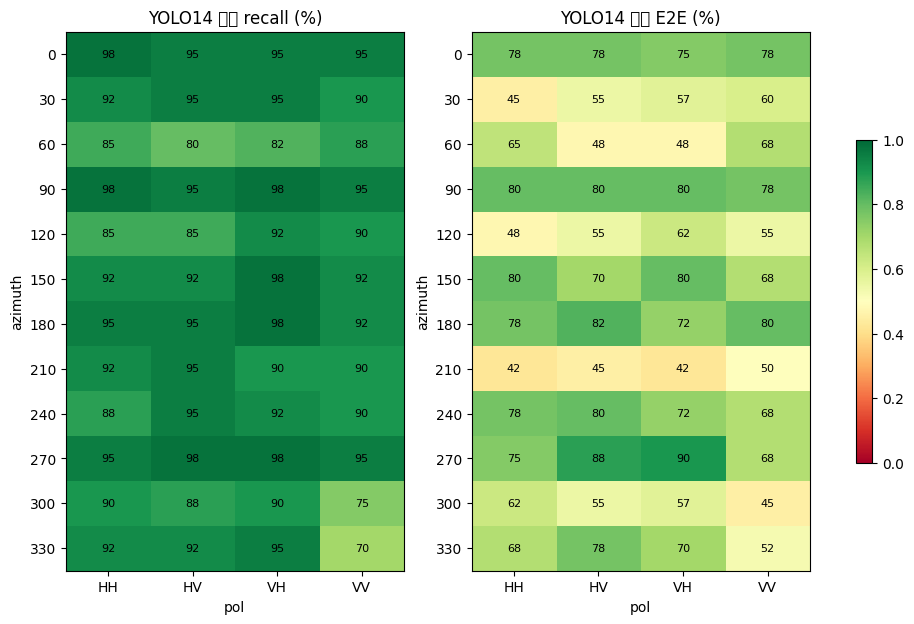

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def heat(ax, piv, title):
    im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_xlabel("pol"); ax.set_ylabel("azimuth"); ax.set_title(title)
    for r in range(piv.shape[0]):
        for c in range(piv.shape[1]):
            v = piv.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v*100:.0f}", ha="center", va="center", fontsize=8)
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
heat(axes[0], df.pivot_table(index="azi", columns="pol", values="recall"), "YOLO14 단독 recall (%)")
im = heat(axes[1], df.pivot_table(index="azi", columns="pol", values="E2E"), "YOLO14 단독 E2E (%)")
fig.colorbar(im, ax=axes, shrink=0.6); plt.show()

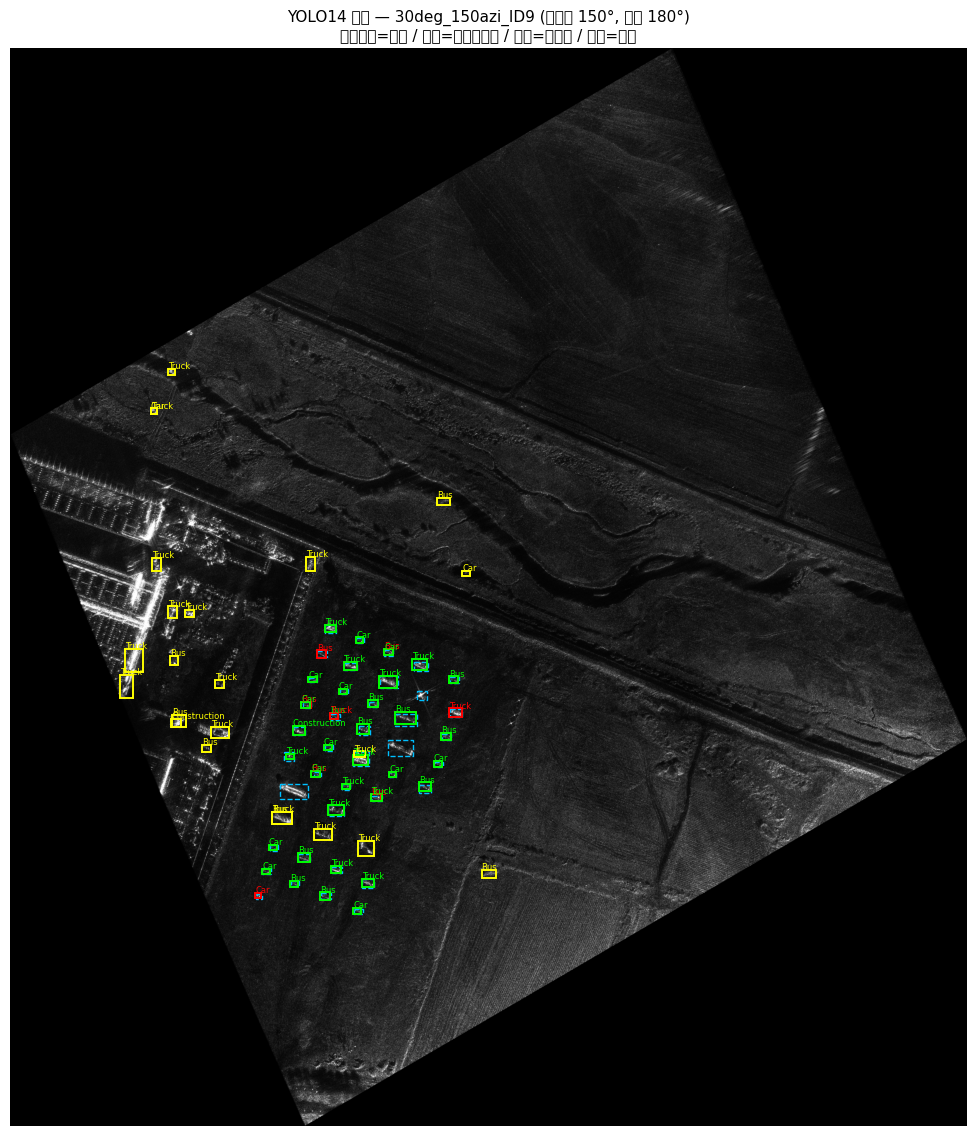

정답 40대 / 탐지 65박스


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ▼ 보고 싶은 장면 인덱스 (0~47). dom_tifs 순서 기준
IDX = 8

p = dom_tifs[IDX]
folder = p.split("/")[-2]
azi = int(re.search(r"(\d+)azi", folder).group(1))
sc = load_rgb(p); gt = load_gt(p)

# 회전 보정 적용해 탐지 (학습 규약으로 복원 후, 박스는 원좌표로)
k = int(round(azi/90)) % 4
rot = rot_k(sc, k)
dets_rot = detect14(rot)                                  # [(box, class), ...] 회전본 좌표
dets = [(inv_box(b, sc.shape[1], sc.shape[0], k), c) for b, c in dets_rot]

# 시각화: 원본 장면 위에 GT(파랑) / 예측(초록=클래스정답, 빨강=오분류)
fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(sc[:, :, 0], cmap="gray")

# 정답 박스 (파란 점선)
for gb, gc in gt:
    x1, y1, x2, y2 = gb
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                 edgecolor="deepskyblue", lw=1.0, ls="--"))

# 예측 박스 — GT와 IoU≥0.3 매칭해 클래스 정답이면 초록, 틀리면 빨강, 미매칭 노랑
for db, dc in dets:
    best_iou, best_gc = 0.3, None
    for gb, gc in gt:
        v = iou(gb, db)
        if v >= best_iou: best_iou, best_gc = v, gc
    color = "yellow" if best_gc is None else ("lime" if dc == best_gc else "red")
    x1, y1, x2, y2 = db
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=color, lw=1.4))
    ax.text(x1, y1-3, dc, color=color, fontsize=6)

r = df[(df.azi==azi)].iloc[0] if 'df' in dir() else None
ax.set_title(f"YOLO14 단독 — {folder} (방위각 {azi}°, 회전 {k*90}°)\n"
             f"파랑점선=정답 / 초록=클래스정답 / 빨강=오분류 / 노랑=오탐", fontsize=11)
ax.axis("off"); plt.show()

print(f"정답 {len(gt)}대 / 탐지 {len(dets)}박스")

## 해석 가이드 — 1단계 vs 2단계
- **recall**: 둘 다 위치는 잘 찾으므로 비슷할 것 (YOLO 탐지 능력 자체는 동일 계열)
- **cls_on_det (분류 정확도)**: 여기서 갈림. YOLO 통합 < 별도 분류기(ConvNeXt)면 → **2단계 설계 정당화**
- **E2E**: 최종 비교 수치

### 예상
논문상 YOLO 통합은 fine-grained에서 약함(SOC-50 mAP 64.4). 14대분류로 쉬워지지만,
여전히 ConvNeXt 전용 분류기보다 낮으면 "탐지·분류 분리가 유효하다"는 결론.
반대로 비슷하면 "이 난이도에선 YOLO 단독으로 충분"이라는 것도 의미있는 결과.